In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
logMmin = 13.0
logMmax = 13.1

odir1 = "../ps_data/snap40/mvir/logM_range"
with open(f"{odir1}/sat_sum/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)

with open(f"{odir1}/sat/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)


In [5]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/tng_toy/logM{logMmin}-{logMmax}"
fname1 = f"{odir1}/tng_toy_sat/r=0-0.5.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)
fname2 = f"{odir1}/tng_toy_sat_sum/r=0-0.5.pickle"
with open(fname2, "rb") as f:
    Pk_mean = pickle.load(f)
    Pk13_gal = pickle.load(f)

In [6]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/tng_toy/logM{logMmin}-{logMmax}"
fname1 = f"{odir1}/tng_toy_gal/r=0-0.5.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum1 = pickle.load(f)
fname2 = f"{odir1}/tng_toy_gal_sum/r=0-0.5.pickle"
with open(fname2, "rb") as f:
    Pk_mean = pickle.load(f)
    Pk13_gal1 = pickle.load(f)

In [7]:
logks_tng = np.log10(Pk13_sum["k"])

In [8]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [9]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)

In [10]:
uk2_13_1 = compute_uk2(Pk13_gal1, Pk13_sum1)

In [11]:
def weight_func(x):
    bin_centers = np.array([  10.756977  ,   12.38553382,   14.26064666,   16.41964296,
         18.90550136,   21.76770729,   25.06323803,   28.85769696,
         33.22661951,   38.25697684,   44.04890713,   50.71770901,
         58.39613682,   67.23704328,   77.41642229,   89.13691246,
        102.63183092,  118.16981794,  136.06018472,  156.65907072,
        180.37653328,  207.68471057,  239.12722026,  275.32998126,
        317.01367372,  365.00808545,  420.2686303 ,  483.89536741,
        557.15489979,  641.50558833,  738.62658305,  850.45124954,
        979.20565607, 1127.4528874 , 1298.14406751, 1494.67710699,
       1720.96434447, 1981.51042862, 2281.50199123, 2626.91089626])
    mean_list = np.array([3.92501983, 7.22222829, 3.12331444, 6.4799078 , 7.23926677,
        2.70870843, 8.10252749, 4.00572676, 7.69409313, 7.85610833,
        2.76831154, 5.38966055, 6.00763836, 3.27590062, 3.34800871,
        3.87145623, 5.13791732, 3.80252985, 3.79223749, 3.31905733,
        4.85240252, 4.85847745, 3.31355529, 2.76880078, 2.62104452,
        2.27062818, 2.06028284, 1.42078321, 0.80132119, 1.54392878,
        1.55019972, 1.87854194, 2.58166134, 1.22951812, 1.36867261,
        1.10317717, 1.52680035, 1.25957019, 3.89913592, 1.6200121
              ])
    y = np.interp(x*1e3, bin_centers,mean_list)
    

    return y

In [12]:
def combined_profile(r, rho0, rs):
    return nfw_profile(r, rho0, rs)*weight_func(r)

In [13]:
def combined_numerical_ft(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax, limit=100)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax, limit=100)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [14]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [15]:
def gaussian(x, mu, sigma):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sigma) * np.exp(-np.power((x - mu) / sigma, 2.0) / 2)
    )

def tot_profile(r, rho0, rs):
    y = ((1/3)*weight_func(r)*nfw_profile(r, rho0, rs))+((2/3)*gaussian(r, mu=0, sigma=0.001)*(1*10**18.2))
    return y

In [16]:
def tot_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * tot_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * tot_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [17]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = combined_numerical_ft(ks, rho0, rs,rvir, rmax=0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:11: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  # This is added back by InteractiveShellApp.init_path()
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:14: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain

In [18]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical1 = tot_ft_numerical(ks, rho0, rs,rvir, rmax=0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  # This is added back by InteractiveShellApp.init_path()
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain f

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


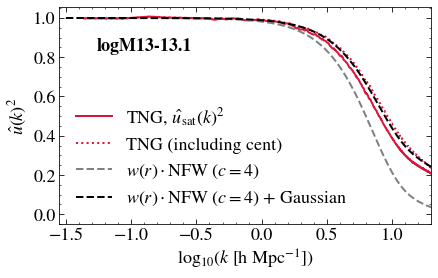

In [19]:
plt.plot(logks_tng, uk2_13, label="TNG, $\hat{u}_{\mathrm{sat}}(k)^2$", c="crimson")
plt.plot(logks_tng, uk2_13_1, label="TNG (including cent)", c="crimson", linestyle="dotted")

#plt.plot(logks_tng, uk2_13_3, label="TNG shuffled 50 r bins")
#plt.plot(logks, uk_nfw**2, label="NFW Ishiyama, logM13, c=4, rvir=0.5cMpc/h")


plt.plot(logks, uk_numerical**2, label="$w(r)\cdot$NFW $(c=4)$", linestyle="dashed", c="grey")
plt.plot(logks, uk_numerical1**2, label="$w(r)\cdot$NFW $(c=4)$ + Gaussian", linestyle="dashed", c="k")

#plt.plot(logks, uk_numerical2**2, label="$c=4, r=0-$0.5 cMpc/h, weighted w cent", linestyle="dashed")

#plt.plot(logks, uk1**2, label="$c=8, r=0-$1.2 cMpc/h, unweighted", linestyle="dashed")
#plt.plot(logks, uk2**2, label="$c=8, r=0-$1.2 cMpc/h, weighted", linestyle="dashed")
#plt.plot(logks, uk3**2, label="$c=4, r=0-$1.5 cMpc/h", linestyle="dashed")

#plt.plot(logks, uk_numerical2**2, label="$c=50, r_{\mathrm{max}}=$1.5 cMpc/h", linestyle="dashed")
#plt.plot(logks, uk_nfw1**2, label="NFW Ishiyama, logM13")
plt.legend()

plt.xlim(-1.55,1.3)

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylabel("$\hat{u}(k)^2$")

ax = plt.gca()
ax.annotate(f"logM13-13.1", (0.1,0.8), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/u_k_logM13_physical.pdf", format="pdf", bbox_inches="tight")